Blochel_eBird_wost.py
Wood Stork Observations Using the eBird API

In [5]:
import os
import requests
import pandas as pd
import matplotlib.pyplot as plt

## API Setup

To download and use eBird data we need to have an API. 


The eBird API requires a free API key. /n
Request one at: https://ebird.org/api/keygen
Either set the `EBIRD_API_KEY` environment variable before starting the notebook, or enter the key securely when the setup cell prompts you.
Wood Stork eBird species code: woosto

In [10]:
from getpass import getpass

API_KEY = os.environ.get("EBIRD_API_KEY")
if not API_KEY:
    API_KEY = getpass("Enter your eBird API key (input hidden): ").strip()
if not API_KEY:
    raise RuntimeError(
        "No eBird API key was provided. Set EBIRD_API_KEY or enter your key when prompted."
    )
SPECIES_CODE = "woosto"          
BASE_URL = "https://api.ebird.org/v2"
HEADERS = {"X-eBirdApiToken": API_KEY}

def get_observations(url, params):
    response = requests.get(url, headers=HEADERS, params=params)
    try:
        response.raise_for_status()
    except requests.HTTPError as exc:
        try:
            details = response.json()
        except ValueError:
            details = response.text
        raise RuntimeError(
            f"eBird API request failed ({response.status_code}): {details}"
        ) from exc

    observations = response.json()
    if not isinstance(observations, list):
        raise RuntimeError(
            f"Expected a list of observations, got {type(observations).__name__}: {observations}"
        )
    return observations

In [11]:
# ------------------------------------------------------------
# Step 1: Test the API — Recent Wood Stork Observations
# ------------------------------------------------------------

url = f"{BASE_URL}/data/obs/US/recent/{SPECIES_CODE}"
params = {"maxResults": 10}

data = get_observations(url, params)
print(f"Number of recent observations retrieved: {len(data)}")

# Inspect the first observation
if not data:
    raise RuntimeError("The eBird API returned no recent Wood Stork observations.")
first_obs = data[0]
print("Date:", first_obs.get("obsDt"))
print("Common name:", first_obs.get("comName"))
print("Scientific name:", first_obs.get("sciName"))
print("Location:", first_obs.get("locName"))
print("State/Province:", first_obs.get("subnational1Code"))
print("How many:", first_obs.get("howMany"))


Number of recent observations retrieved: 10
Date: 2026-10-07 19:55
Common name: Wood Stork
Scientific name: Mycteria americana
Location: Parrish Park/Max Brewer Causeway
State/Province: None
How many: 2


            State  Observations
0         Florida           200
1         Georgia           128
2  South Carolina           200
3  North Carolina            30
4         Alabama            25
5     Mississippi            26
6       Louisiana            29
7           Texas           148


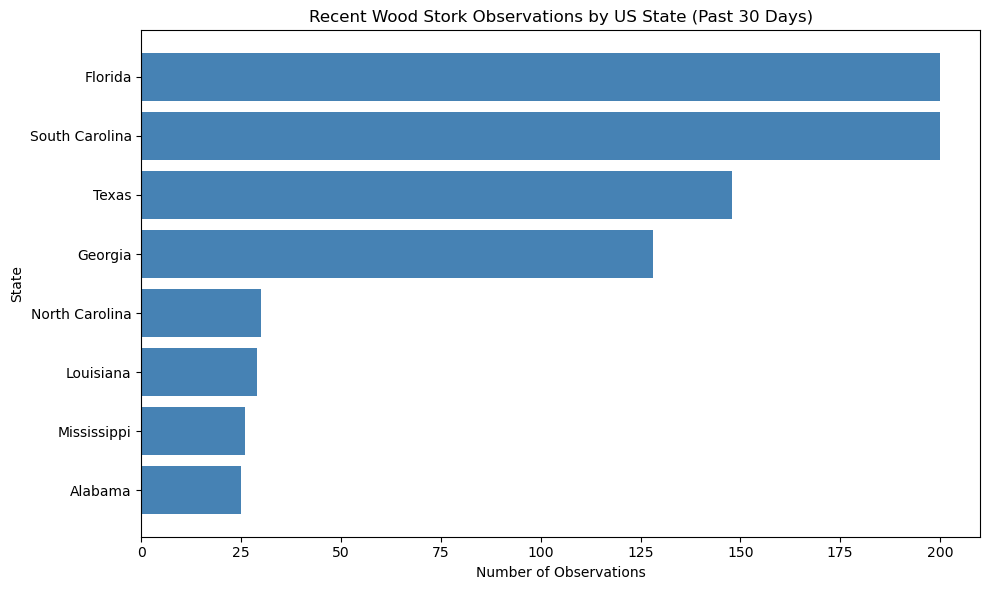

In [12]:


# ------------------------------------------------------------
# Step 2: Recent Observations by Southeastern US State
# ------------------------------------------------------------

states = {
    "Florida": "US-FL",
    "Georgia": "US-GA",
    "South Carolina": "US-SC",
    "North Carolina": "US-NC",
    "Alabama": "US-AL",
    "Mississippi": "US-MS",
    "Louisiana": "US-LA",
    "Texas": "US-TX"
}

state_counts = []

for state_name, state_code in states.items():
    url = f"{BASE_URL}/data/obs/{state_code}/recent/{SPECIES_CODE}"
    params = {"maxResults": 200, "back": 30}  # past 30 days
    obs = get_observations(url, params)
    count = len(obs)
    state_counts.append({"State": state_name, "Observations": count})

state_df = pd.DataFrame(state_counts)
print(state_df)

# Bar chart: recent Wood Stork observations by state
state_df_sorted = state_df.sort_values("Observations", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(state_df_sorted["State"], state_df_sorted["Observations"], color="steelblue")
plt.title("Recent Wood Stork Observations by US State (Past 30 Days)")
plt.xlabel("Number of Observations")
plt.ylabel("State")
plt.tight_layout()
plt.show()



Total observations in sample: 200
                 date common_name     scientific_name  \
0 2026-10-07 19:55:00  Wood Stork  Mycteria americana   
1 2026-10-07 18:41:00  Wood Stork  Mycteria americana   
2 2026-10-07 17:49:00  Wood Stork  Mycteria americana   
3 2026-10-07 17:48:00  Wood Stork  Mycteria americana   
4 2026-10-07 17:24:00  Wood Stork  Mycteria americana   

                           location state  how_many   latitude  longitude  
0  Parrish Park/Max Brewer Causeway  None       2.0  28.623706 -80.794487  
1  Huntington Beach SP--Mullet Pond  None      14.0  33.507587 -79.069181  
2         Lake house Ocala preserve  None       1.0  29.225879 -82.210709  
3                       Lake Howell  None       1.0  28.639877 -81.309439  
4                 Burton 4-H Center  None       2.0  32.007428 -80.851511  
location
Huntington Beach SP--Mullet Pond         2
M&M Dairy (Port Jacksonville Parkway)    2
Rivers Edge Public Nature Trail          2
Sweetwater Wetlands Park     

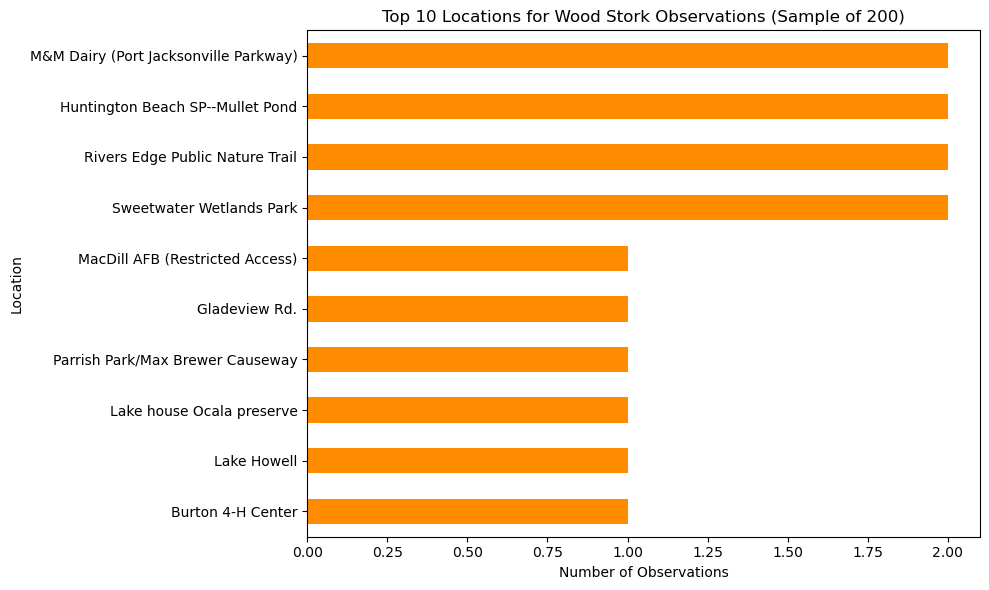

In [13]:

# ------------------------------------------------------------
# Step 3: Larger Sample — Build a Structured DataFrame
# ------------------------------------------------------------

url = f"{BASE_URL}/data/obs/US/recent/{SPECIES_CODE}"
params = {"maxResults": 200, "back": 30}

all_obs = get_observations(url, params)

records = []
for obs in all_obs:
    records.append({
        "date": obs.get("obsDt"),
        "common_name": obs.get("comName"),
        "scientific_name": obs.get("sciName"),
        "location": obs.get("locName"),
        "state": obs.get("subnational1Code"),
        "how_many": obs.get("howMany"),
        "latitude": obs.get("lat"),
        "longitude": obs.get("lng")
    })

df = pd.DataFrame(records)
df["date"] = pd.to_datetime(df["date"])
print(f"Total observations in sample: {len(df)}")
print(df.head())


# ------------------------------------------------------------
# Step 4: Top 10 Locations with the Most Wood Stork Sightings
# ------------------------------------------------------------

top_locations = df["location"].value_counts().head(10)
print(top_locations)

plt.figure(figsize=(10, 6))
top_locations.sort_values().plot(kind="barh", color="darkorange")
plt.title("Top 10 Locations for Wood Stork Observations (Sample of 200)")
plt.xlabel("Number of Observations")
plt.ylabel("Location")
plt.tight_layout()
plt.show()